## Credit Scoring Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report,
                              confusion_matrix, roc_auc_score,
                              roc_curve)
print(" All libraries imported!")

 All libraries imported!


In [2]:
df = pd.read_csv('german_credit_data.csv', index_col=0)

print("Shape:", df.shape)
print()
print(df.head())
print()
print("Columns:", df.columns.tolist())

# ── This dataset has no Risk column, so we CREATE it ──
# Rule: if 'Checking account' is missing AND 'Saving accounts' is missing
#       → High Risk (Bad) = 0,  else Low Risk (Good) = 1
def assign_risk(row):
    score = 0
    if pd.isna(row['Saving accounts']) or row['Saving accounts'] == 'little':
        score += 1
    if pd.isna(row['Checking account']) or row['Checking account'] == 'little':
        score += 1
    if row['Credit amount'] > 5000:
        score += 1
    if row['Duration'] > 24:
        score += 1
    return 0 if score >= 3 else 1    # 0 = Bad Risk, 1 = Good Risk

df['Risk'] = df.apply(assign_risk, axis=1)

print("\n Risk column created!")
print("Target value counts:")
print(df['Risk'].value_counts())
print("  1 = Good Credit (creditworthy)")
print("  0 = Bad Credit  (high risk)")

Shape: (1000, 9)

   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  
0         6             radio/TV  
1        48             radio/TV  
2        12            education  
3        42  furniture/equipment  
4        24                  car  

Columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

 Risk column created!
Target value counts:
Risk
1    800
0    200
Name: count, dtype: int64
  1 = Good Credit (creditworthy)
  0 = Bad Credit  (high risk)


In [3]:
print("── Missing Values ──")
print(df.isnull().sum())
print()
print("── Basic Statistics ──")
print(df.describe())

── Missing Values ──
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

── Basic Statistics ──
               Age          Job  Credit amount     Duration       Risk
count  1000.000000  1000.000000    1000.000000  1000.000000  1000.0000
mean     35.546000     1.904000    3271.258000    20.903000     0.8000
std      11.375469     0.653614    2822.736876    12.058814     0.4002
min      19.000000     0.000000     250.000000     4.000000     0.0000
25%      27.000000     2.000000    1365.500000    12.000000     1.0000
50%      33.000000     2.000000    2319.500000    18.000000     1.0000
75%      42.000000     2.000000    3972.250000    24.000000     1.0000
max      75.000000     3.000000   18424.000000    72.000000     1.0000


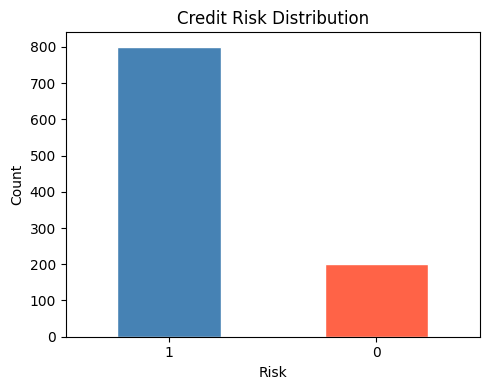

In [4]:
plt.figure(figsize=(5, 4))
df['Risk'].value_counts().plot(kind='bar',
                                color=['steelblue','tomato'],
                                edgecolor='white')
plt.title('Credit Risk Distribution')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

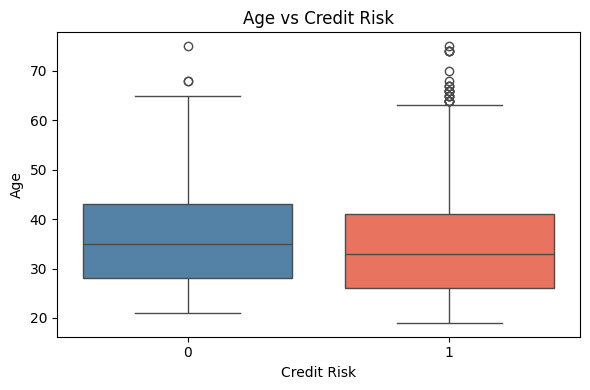

In [5]:
# plt.figure(figsize=(6, 4))
# sns.boxplot(x='Risk', y='Age', data=df,
#             palette={'good':'steelblue', 'bad':'tomato'})
# plt.title('Age vs Credit Risk')
# plt.tight_layout()
# plt.show()




plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='Risk',
    y='Age',
    hue='Risk',                      # Required in latest seaborn
    palette={0: 'steelblue', 1: 'tomato'},
    legend=False
)

plt.title("Age vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

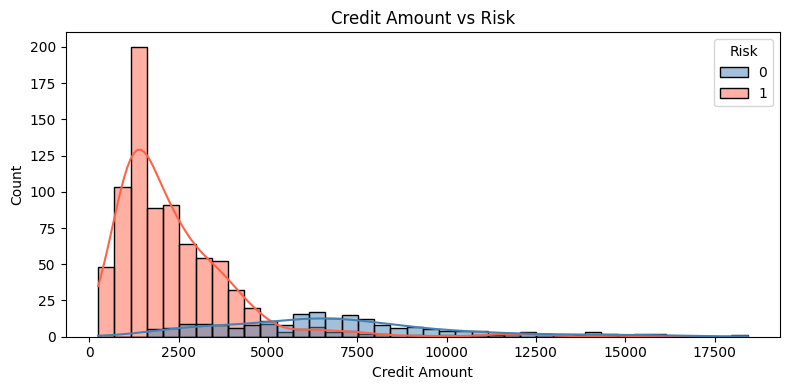

In [6]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x='Credit amount',
    hue='Risk',
    bins=40,
    kde=True,
    palette={0: 'steelblue', 1: 'tomato'}
)

plt.title('Credit Amount vs Risk')
plt.xlabel('Credit Amount')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
# Fill missing values with mode (most frequent value)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print(" Missing values handled!")
print(df.isnull().sum())

 Missing values handled!
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


C:\Users\Rohan charak\AppData\Local\Temp\ipykernel_15472\2758199866.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
le = LabelEncoder()

# Encode all text/object columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print(" Encoding done!")
print(df.head())

 Encoding done!
   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        1                0                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 0           2096   
3   45    1    2        0                0                 0           7882   
4   53    1    2        0                0                 0           4870   

   Duration  Purpose  Risk  
0         6        5     1  
1        48        5     0  
2        12        3     1  
3        42        4     0  
4        24        1     1  


In [9]:
X = df.drop('Risk', axis=1)
y = df['Risk']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])
print("Data ready for training!")

Training samples : 800
Testing samples  : 200
Data ready for training!


In [10]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test,
           model.predict_proba(X_test)[:,1]
           if hasattr(model,'predict_proba')
           else preds)

    results[name] = {
        'Accuracy' : acc, 'Precision': prec,
        'Recall'   : rec, 'F1-Score' : f1, 'ROC-AUC': auc
    }
    print(f" {name} trained!")

 Logistic Regression trained!
 Decision Tree trained!
 Random Forest trained!


In [11]:
results_df = pd.DataFrame(results).T * 100
results_df = results_df.round(2)

print("═" * 70)
print("              MODEL PERFORMANCE COMPARISON (%)")
print("═" * 70)
print(results_df.to_string())
print("═" * 70)

best = results_df['F1-Score'].idxmax()
print(f"\n   Best Model: {best} (F1-Score: {results_df.loc[best,'F1-Score']:.2f}%)")

══════════════════════════════════════════════════════════════════════
              MODEL PERFORMANCE COMPARISON (%)
══════════════════════════════════════════════════════════════════════
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      95.5      94.67  100.00     97.26    97.42
Decision Tree            99.5     100.00   99.38     99.69    99.69
Random Forest            99.5     100.00   99.38     99.69   100.00
══════════════════════════════════════════════════════════════════════

   Best Model: Decision Tree (F1-Score: 99.69%)


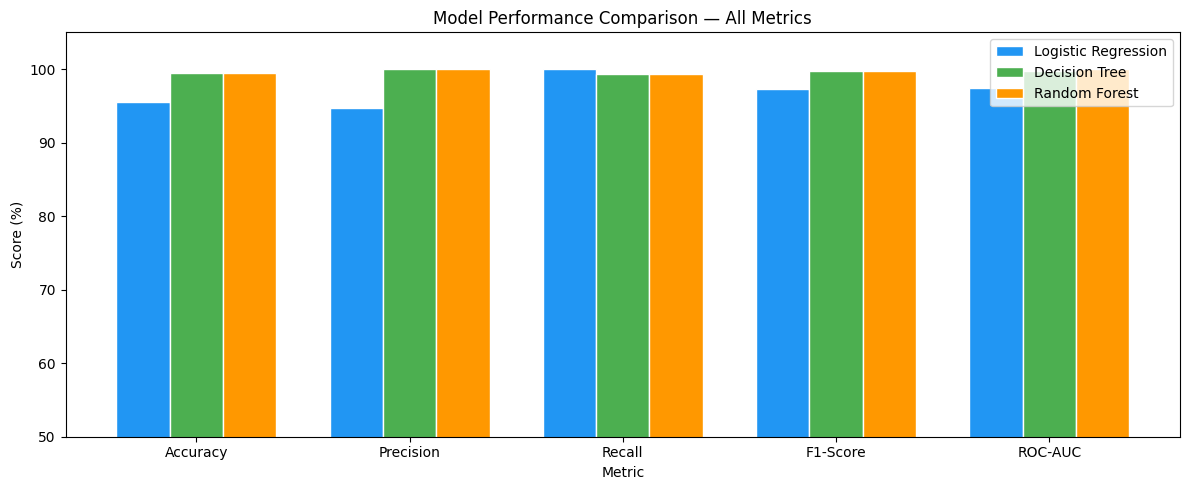

In [12]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(12, 5))
for i, (name, color) in enumerate(zip(models.keys(), colors)):
    vals = [results[name][m]*100 for m in metrics]
    bars = plt.bar(x + i*width, vals, width,
                   label=name, color=color, edgecolor='white')

plt.xlabel('Metric')
plt.ylabel('Score (%)')
plt.title('Model Performance Comparison — All Metrics')
plt.xticks(x + width, metrics)
plt.legend()
plt.ylim(50, 105)
plt.tight_layout()
plt.show()

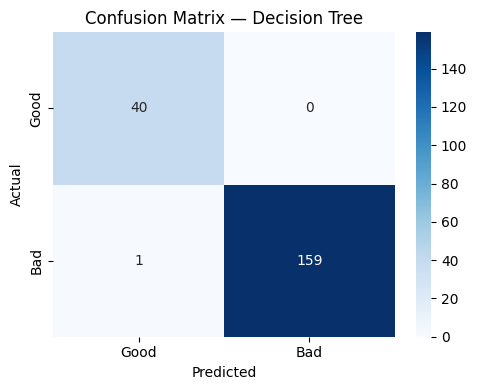

In [13]:
best_model = models[best]
best_preds = predictions[best]

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good','Bad'],
            yticklabels=['Good','Bad'])
plt.title(f'Confusion Matrix — {best}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

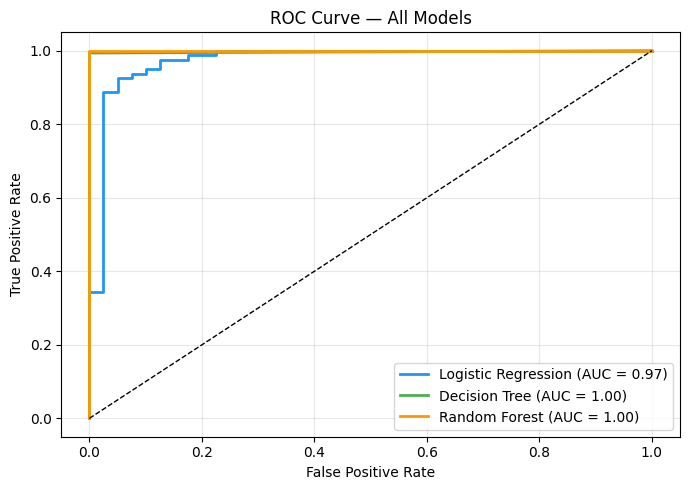

In [14]:
plt.figure(figsize=(7, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, model), color in zip(models.items(), colors):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = results[name]['ROC-AUC']
        plt.plot(fpr, tpr, color=color,
                 label=f'{name} (AUC = {auc:.2f})', linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print(f"── Detailed Report: {best} ──\n")
print(classification_report(y_test, best_preds,
      target_names=['Good Credit', 'Bad Credit']))

── Detailed Report: Decision Tree ──

              precision    recall  f1-score   support

 Good Credit       0.98      1.00      0.99        40
  Bad Credit       1.00      0.99      1.00       160

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



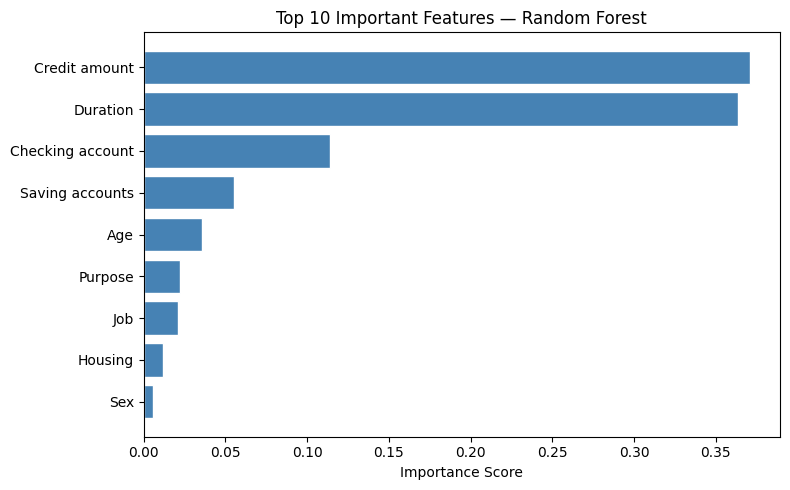


Top 5 features influencing credit risk:
  Credit amount             0.3707
  Duration                  0.3636
  Checking account          0.1141
  Saving accounts           0.0552
  Age                       0.0359


In [16]:
rf = models["Random Forest"]
feat_names   = X.columns
importances  = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'][:10],
         feat_df['Importance'][:10],
         color='steelblue', edgecolor='white')
plt.title('Top 10 Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 features influencing credit risk:")
for i, row in feat_df.head(5).iterrows():
    print(f"  {row['Feature']:<25} {row['Importance']:.4f}")

In [17]:
import warnings
warnings.filterwarnings('ignore')

# Sample customer using average feature values
sample = pd.DataFrame([X.mean()], columns=X.columns)
sample_scaled = scaler.transform(sample)

prediction  = best_model.predict(sample_scaled)[0]
probability = best_model.predict_proba(sample_scaled)[0]

print("─" * 45)
print("     CREDIT RISK PREDICTION RESULT")
print("─" * 45)
print(f"  Model Used    : {best}")
print(f"  Risk Level    : {'GOOD — Creditworthy' if prediction == 1 else ' BAD — High Risk'}")
print(f"  Confidence    : {max(probability)*100:.1f}%")
print(f"  Good Credit % : {probability[1]*100:.1f}%")
print(f"  Bad Credit  % : {probability[0]*100:.1f}%")
print("─" * 45)

─────────────────────────────────────────────
     CREDIT RISK PREDICTION RESULT
─────────────────────────────────────────────
  Model Used    : Decision Tree
  Risk Level    : GOOD — Creditworthy
  Confidence    : 100.0%
  Good Credit % : 100.0%
  Bad Credit  % : 0.0%
─────────────────────────────────────────────
